In [1]:
# вычисление и визуализация
# численного решения нестационарного
# уравнения Шредингера

# Ячейка № 1

# подключение библиотеки numpy
import numpy as np

# подключение библиотеки matplotlib.pyplot
import matplotlib.pyplot as plt


In [2]:
# Ячейка № 2

# задание функции,
# возвращающей значения высоты
# прямоугольного потенциального барьера
# (барьер № 1)
def Rect(x, V0, x0, A):
    # x - массив, содержащий
    #     значения координат
    #     используемой сетки по переменной х
    # V0 - переменная, задающая
    #      максимальную высоту барьера
    # x0 - переменная, задающая значение абцисcы
    #      средней точки отрезка, на котором
    #      значения потенциального барьера максимальны
    # A - переменная, определяющая
    #     максимальную ширину
    #     потенциального барьера

    # определение числа
    # узлов используемой
    # координатной сетки
    N_Grid = len(x)

    # инициализация массива,
    # используемого для
    # хранения значений высоты
    # прямоугольного барьера
    z = np.zeros(N_Grid)

    # вычисление в узлах координатной сетки
    # значениий высоты
    # прямоугольного барьера
    for i in range(N_Grid):
        if (x[i] >= x0 - A / 2) and (x[i] <= x0 + A / 2):
            z[i] = V0
        else:
            z[i] = 0

    return z

In [3]:
# Ячейка № 3

# задание функции,
# возвращающей значения высоты
# потенциального барьера,
# описываемого гауссовой функцией
# (барьер № 2)
def Gauss(x, V0, x0, A):
    # x - массив, содержащий
    #     значения координат
    #     используемой сетки по переменной х
    # V0 - переменная, задающая
    #      максимальную высоту барьера
    # x0 - переменная, задающая значение
    #      абцисcы, в которой
    #      значение потенциального барьера
    #      имеет максимальное значение
    # A - переменная, определяющая
    #     максимальную ширину
    #     потенциального барьера

    # определение числа
    # узлов используемой
    # координатной сетки
    N_Grid = len(x)

    # инициализация массива,
    # используемого для
    # хранения значений
    # высоты потенциального барьера,
    # описываемого гауссовой функцией
    z = np.zeros(N_Grid)

    # вычисление в узлах координатной сетки
    # значений высоты
    # потенциального барьера,
    # описываемого потенциальной функцией
    for i in range(N_Grid):
        z[i] = V0 * np.exp(-((x[i] - x0) ** 2) * np.log10(20) / A**2)

    return z

In [4]:
# Ячейка № 4

# задание функции,
# возвращающей значения высоты
# потенциального барьера,
# описываемого функцией арктангенс
# (барьер № 3)
def Step_B(x, V0, x0, A):
    # x - массив, содержащий
    #     значения координат
    #     используемой сетки по переменной х
    # V0 - переменная, задающая
    #      максимальную высоту барьера
    # x0 - переменная, задающая значение абсциссы
    #      в которой значение
    #      потенциального барьера равняется
    #      его среднему значению
    # A - переменная, определяющая
    #     размер области, в которой
    #     высота потенциального барьера
    #     изменятся от своего минимального
    #     до максимального значений

    # определение числа
    # узлов используемой
    # координатной сетки
    N_Grid = len(x)

    # инициализация массива,
    # используемого для
    # хранения значений
    # высоты барьера,
    # описываемого функцией арктангенс
    z = np.zeros(N_Grid)

    # вычисление в узлах координатной сетки
    # значений высоты
    # потенциального барьера,
    # описываемого функцией арктангенс
    for i in range(N_Grid):
        z[i] = 0.5 * V0 * (np.arctan((x[i] - x0) * 2 * 6.313 / A * 2 / np.pi) + 1)
    z = z - z[0]

    return z

In [5]:
# Ячейка № 5

# задание функции,
# возвращающей значения высоты
# потенциального барьера, описываемого
# квадратической функцией
# (барьер № 4)
def Parabolic(x, V0, x0, A):
    # x - массив, содержащий
    #     значения координат
    #     используемой сетки по переменной х
    # V0 - переменная, задающая
    #      максимальную высоту барьера
    # x0 - переменная, задающая значение
    #      абсциссы, в которой
    #      значение потенциального барьера
    #      имеет максимальное значение
    # A - переменная, определяющая
    #     максимальную ширину барьера

    # определение числа
    # узлов используемой
    # координатной сетки
    N_Grid = len(x)

    # инициализация массива,
    # используемого для
    # хранения значений высоты
    # потенциального барьера, описываемого
    # квадратической функцией
    z = np.zeros(N_Grid)

    # вычисление в узлах координатной сетки
    # значений высоты
    # потенциального барьера, описываемого
    # квадратической функцией
    for i in range(N_Grid):
        if (x[i] >= x0 - A / 2) and (x[i] <= x0 + A / 2):
            z[i] = -V0 * (2 / A) ** 2 * (x[i] - x0) ** 2 + V0
        else:
            z[i] = 0

    return z

In [6]:
# Ячейка № 6

# задание функции, обеспечивающей
# выбор типа потенциального барьера,
# указанием соответствующего номера
def Barrier(Mode_Barrier, x, V0, x0, A):
    # Mode_Barrier - номер используемого
    #                потенциального барьера
    # x - массив, содержащий
    #     значения координат
    #     используемой сетки по переменной х
    # V0 - переменная, задающая
    #      максимальную высоту барьера
    # x0 - переменная, задающая значение
    #      абсциссы, в которой
    #      значение потенциального барьера
    #      имеет максимальное значение
    # A - переменная, определяющая
    #     максимальную ширину барьера

    if Mode_Barrier == 1:
        z = Rect(x, V0, x0, A)

    if Mode_Barrier == 2:
        z = Gauss(x, V0, x0, A)

    if Mode_Barrier == 3:
        z = Step_B(x, V0, x0, A)

    if Mode_Barrier == 4:
        z = Parabolic(x, V0, x0, A)

    return z


In [7]:
# Ячейка № 7

# задание функции, возвращающей значения
# действительной и мнимой частей пакета
def Package(Mode_Package, x, k0, x0_Package, Sigma):
    # Mode_Package - выбранный тип пакета:
    #                1 - пакет с гауссовой огибающей
    #                2 - пакет с релеевской огибающей
    # x - массив, содержащий
    #     значения координат
    #     используемой сетки по переменной х
    # k0 - значение волнового вектора пакета
    # x0_Package- переменная, задающая абсциссу,
    #             в которой значение огибающей
    #             волнового пакета максимально
    # Sigma - переменная, определяющая
    #         максимальную ширину пакета

    # определение числа
    # узлов используемой
    # координатной сетки
    N_Grid = len(x)

    # инициализация комплекснозначного массива,
    # используемого для размещения
    # вычисленных значений функции,
    # описывающей пакет
    z = np.zeros(N_Grid, dtype="complex_")

    if Mode_Package == 1:
        # вычисление значений функции,
        # описывающей гауссов пакет
        for i in range(N_Grid):
            z[i] = (
                np.exp(1j * k0 * x[i])
                * 0.9
                * np.exp(-((x[i] - x0_Package) ** 2) * np.log10(2) / Sigma**2)
            )

    if Mode_Package == 2:
        # вычисление значений функции,
        # описывающей релеевский пакет
        for i in range(N_Grid):
            z[i] = (
                np.exp(1j * k0 * x[i])
                * Sigma**2
                / (Sigma**2 + (x[i] - x0_Package) ** 2)
            )

    # вычисление нормировочного коэффициента
    A = np.trapz(np.abs(z) ** 2, x)

    # нормировка значений пакета
    z = z / np.sqrt(A)

    return z


In [8]:
# Ячейка № 8

# задание функций, возвращающих
# значения коэффициентов gamma,
# вычисляемых в соответствие c (16.64)
# разностной схемы, используемой
# для решения нестационарного уравнения Шредингера
# методом прогонки
def Coeff(dt, dx, V):
    # dt - значение шага по времени
    # dx - значение шага по координате
    # V - массив, содержащий значения
    # функции, описывающей потенциальный барьер

    # опредение размера массива V
    N_Points = len(V)

    # инициализация комплекснозначного массива,
    # используемого для хранения значений коэффициентов,
    # вычисляемых в соответствие с (16.60)
    Az = np.zeros(N_Points, dtype="complex_")

    # инициализация комплекснозначного массива,
    # используемого для хранения значений коэффициентов,
    # вычисляемых в соответствие с (16.65)
    Alpha = np.zeros(N_Points - 1, dtype="complex_")

    # инициализация комплекснозначного массива,
    # используемого для хранения значения коэффициентов,
    # вычисляемых в соответствие с (16.64)
    Gamma = np.zeros(N_Points, dtype="complex_")

    # вычисление значений коэффициентов A0
    # в соответствие с (16.60)
    for k in range(N_Points):
        Az[k] = -2 + 2j * dx**2 / dt - dx**2 * V[k]

    # вычисление значений коэффициентов:
    # alpha в соответствие с (16.67),
    # gamma в соответствие с (16.68)
    Alpha[N_Points - 2] = 0
    Gamma[N_Points - 1] = -1 / Az[N_Points - 1]
    k = N_Points - 1
    while k >= 1:
        Alpha[k - 1] = Gamma[k]
        Gamma[k - 1] = -1 / (Az[k - 1] + Alpha[k - 1])
        k = k - 1

    return Gamma


In [9]:
# Ячейка № 9

# задание функции, возвращающей
# численные решения
# нестационарного уравнения Шредингера
# методом прогонки
def Psi(Coeff, Psi, dx, dt, x):
    # Coeff - массив значений коэффициентов,
    #         возвращенный функцией Coeff

    # определение длины массива, содержащего
    # значения пакета в момент времени на
    # предыдущем шаге интегрирования
    N_Points = len(Psi)

    # инициализация комплекснозначного массива,
    # используемого для хранения коэффициентов beta,
    # вычисляемых в соответствие с (16.66)
    Beta = np.zeros(N_Points, dtype="complex_")

    # инициализация комплекснозначного массива,
    # используемого для хранения коэффициентов beta,
    # вычисляемых в соответствие с (16.66)
    Xi = np.zeros(N_Points, dtype="complex_")

    # вычисление значений коэффициентов beta
    # в соответствие с (16.69) (обратный ход)
    Beta[N_Points - 1] = 0 + 0j
    k = N_Points - 1
    while k >= 1:
        Beta[k - 1] = Coeff[k] * (Beta[k] - 4j * dx**2 / dt * Psi[k])
        k = k - 1
    # вычисление значений функции Xi
    # на следующем шаге интегрирования
    # в соответствие с (16.61)
    Xi[0] = 0 + 0j
    for k in range(N_Points - 2):
        Xi[k + 1] = Coeff[k] * Xi[k] + Beta[k]
        # вычисление значений
        # численного решения уравнения Шредингера
        # на следующем шаге интегрирования
        # в соответствие с (16.53)
        Psi[k + 1] = Xi[k + 1] - Psi[k + 1]

    # вычисление нормировочной коэффициента
    B = np.trapz(np.abs(Psi) ** 2)

    # возвращение в вызыващую функцию
    # нормированного решения уравнения Шредингера
    return Psi / np.sqrt(B)


In [ ]:
# Ячейка № 10

# вычисление численного решения
# нестационарного уравнения Шредингера

# задание значения
# крайне левого узла
# координатной сетки
X_min = -300

# задание значения
# крайне правого узла
# координатной сетки
X_max = 300

# задание числа узлов
# координатной сетки
N_Points = 2000

# вычисление значений
# координат узлов выбранной сетки
x = np.linspace(X_min, X_max, N_Points)

# задание шага интегрирования
# уравнения Шредингера по времени
dt = 0.5

# задание число шагов интегрирования
# уравнения Шредингера по времени
N_t = 801

# выбор типа пакета
Mode_Package = 2  # релеевский пакет

# задание значения волнового вектора
k0 = 0.5

# задание значения абсциссы,
# в которой огибающая волнового пакета
# максимальна
x0_Package = -100

# задание значения переменной,
# определяющей максимальную ширину пакета
Sigma = 2

# вычисление значений пакета
# в начальный момент времени
z = Package(
    Mode_Package,
    x,
    k0,
    x0_Package,
    Sigma,
)

# выбор типа потенциального барьера
Mode_Barrier = 4  # параболический потенциальный барьер
# задание параметров
# выбранного потенциального барьера
V0 = 1.5
x0 = 0
A = 60

# вычисление значений выбранного
# потенциального барьера
# в узлах координатной сетки
V = Barrier(
    Mode_Barrier,
    x,
    V0,
    x0,
    A,
)

# вычисление коэффициентов gamma
# в соответствие c (16.64)
C = Coeff(dt, x[1] - x[0], V)

# инициализация массива Z размерности N_Points * Nt,
# используемого для сохранения численных решений
# уравнения Шредингера на каждом шаге интегрирования
Z = np.zeros([N_Points, N_t], dtype="complex_")

# размещение в массиве Z решения уравнения Шредингера,
# вычисленного в начальный момент времени
Z[:, 0] = z[:]

# вычисление  решений уравнения Шредингера
# в последующие моменты времени
for i in range(1, N_t):
    Z[:, i] = Psi(C, Z[:, i - 1], x[1] - x[0], dt, x)

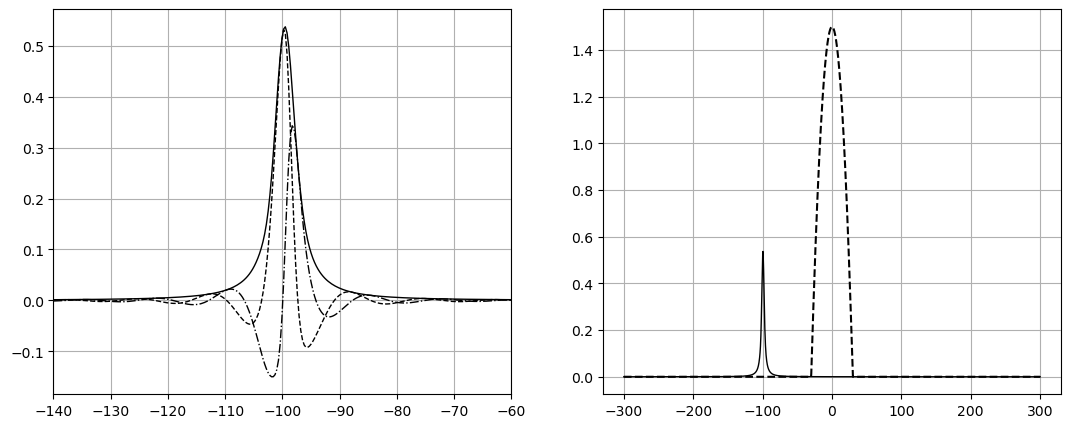

In [11]:
# Ячейка № 11

# визуализация решения нестационарного
# уравнения Шредингера в начальный момент времени

fig = plt.figure(figsize=(13, 11))

# визуализация действительной, мнимой частей
# и огибающей численного решения
# нестационарного уравнения Шредингера
# в начальный момент времени
ax = plt.subplot(2, 2, 1)
plt.plot(x, np.real(Z[:, 0]), "--k", lw=1)
plt.plot(x, np.imag(Z[:, 0]), "-.k", lw=1)
plt.plot(x, np.abs(Z[:, 0]), "-k", lw=1)
plt.grid(True)
plt.xlim([-140, -60])

ax = plt.subplot(2, 2, 2)
plt.plot(x, np.abs(Z[:, 0]), "k", lw=1)
plt.plot(x, V, "--k")
plt.grid(True)

plt.show()


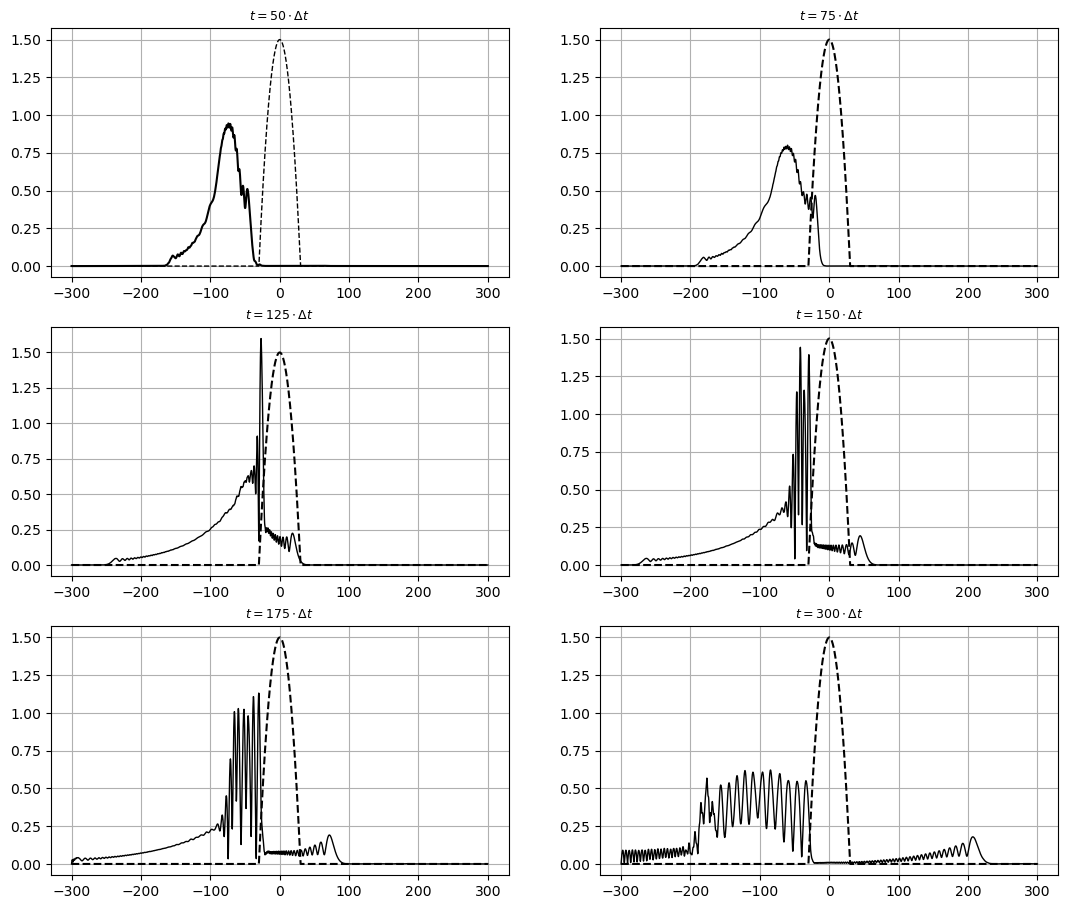

In [12]:
# Ячейка № 12

# визуализация действительной, мнимой частей
# и огибающей численного решения
# нестационарного уравнения Шредингера
# в выбранные моменты времени

fig = plt.figure(figsize=(13, 11))

ax = plt.subplot(3, 2, 1)
plt.plot(x, np.abs(Z[:, 51]) * 10, "k")
plt.plot(x, V, "--k", lw=1)
plt.grid(True)
ax.set_title(r"$t = 50 \cdot \Delta t$", fontsize=9)

ax = plt.subplot(3, 2, 2)
plt.plot(x, np.abs(Z[:, 76]) * 10, "k", lw=1)
plt.plot(x, V, "--k")
plt.grid(True)
ax.set_title(r"$t = 75 \cdot \Delta t$", fontsize=9)

ax = plt.subplot(3, 2, 3)
plt.plot(x, np.abs(Z[:, 126]) * 10, "k", lw=1)
plt.plot(x, V, "--k")
plt.grid(True)
ax.set_title(r"$t = 125 \cdot \Delta t$", fontsize=9)

ax = plt.subplot(3, 2, 4)
plt.plot(x, np.abs(Z[:, 151]) * 10, "k", lw=1)
plt.plot(x, V, "--k")
plt.grid(True)
ax.set_title(r"$t = 150 \cdot \Delta t$", fontsize=9)

ax = plt.subplot(3, 2, 5)
plt.plot(x, np.abs(Z[:, 176]) * 10, "k", lw=1)
plt.plot(x, V, "--k")
plt.grid(True)
ax.set_title(r"$t = 175 \cdot \Delta t$", fontsize=9)

ax = plt.subplot(3, 2, 6)
plt.plot(x, np.abs(Z[:, 300]) * 10, "k", lw=1)
plt.plot(x, V, "--k")
plt.grid(True)
ax.set_title(r"$t = 300 \cdot \Delta t$", fontsize=9)

plt.show()